# Markowitz Portfolio Optimization with Bootstrapping

This notebook applies a Markowitz-style optimization workflow to a chosen set of ETFs and averages portfolio weights across return splits.

It is the most complete portfolio-optimization notebook in this folder.


In [12]:
import numpy as np
import matplotlib.pyplot as plt
import cvxopt as opt
from cvxopt import blas, solvers
import pandas as pd
import yfinance as yf

class PortfolioOptimizer:
    def __init__(self, tickers, start_date, end_date, splits=10):
        self.tickers = tickers
        self.start_date = start_date
        self.end_date = end_date
        self.splits = splits
        self.data = None
        self.returns = None
        self.weights_list = []

    def fetch_data(self):
        data = yf.download(self.tickers, start=self.start_date, end=self.end_date, auto_adjust = False)['Adj Close']
        self.data = data
        self.returns = np.log(data / data.shift(1)).dropna().values.T

    def optimize_portfolio(self, returns):
        n = returns.shape[0]
        returns = np.asmatrix(returns)
        S = opt.matrix(np.cov(returns))
        pbar = opt.matrix(np.mean(returns, axis=1))

        G = -opt.matrix(np.eye(n))
        h = opt.matrix(0.0, (n, 1))
        A = opt.matrix(1.0, (1, n))
        b = opt.matrix(1.0)

        sol = solvers.qp(S, -pbar, G, h, A, b)
        return np.array(sol['x']).flatten()

    def run_optimization(self):
        if self.returns is None or len(self.returns) == 0:
            raise ValueError('No returns data to optimize.')
        split_returns = np.array_split(self.returns, self.splits, axis=1)
        for split in split_returns:
            if split.shape[1] > 1:  # Only proceed if there's enough data
                try:
                    weights = self.optimize_portfolio(split)
                    self.weights_list.append(weights)
                except Exception as e:
                    print(f'Solver failed for a chunk: {e}')
                    continue
        if not self.weights_list:  # Check if no successful optimizations
            raise ValueError('All optimizations failed.')
        return np.mean(self.weights_list, axis=0)
        split_returns = np.array_split(self.returns, self.splits, axis=1)
        for split in split_returns:
            try:
                weights = self.optimize_portfolio(split)
                self.weights_list.append(weights)
            except:
                print("Solver failed for a chunk, skipping")
                continue
        return np.mean(self.weights_list, axis=0)

    def calculate_metrics(self, weights):
        annualized_return = np.mean(self.returns, axis=1) * 252
        annualized_cov = np.cov(self.returns) * 252
        port_return = weights @ annualized_return
        port_risk = np.sqrt(weights @ annualized_cov @ weights)
        return port_return, port_risk

    def plot_results(self, avg_weights, full_weights, returns_full, risks_full):
        plt.figure(figsize=(10, 6))
        plt.plot(np.sqrt(252)*np.array(risks_full), 252*np.array(returns_full), 'y-o', label='Efficient Frontier')
        plt.scatter(np.sqrt(252)*self.full_risk, 252*self.full_return, marker='X', color='red', s=200, label='Single Optimization')
        plt.scatter(self.avg_risk*np.sqrt(252), self.avg_return*252, marker='*', color='green', s=200, label='Averaged Weights')
        plt.title('Portfolio Optimization Comparison')
        plt.xlabel('Annualized Volatility')
        plt.ylabel('Annualized Return')
        plt.legend()
        plt.show()

    def run(self):
        self.fetch_data()
        avg_weights = self.run_optimization()
        self.avg_return, self.avg_risk = self.calculate_metrics(avg_weights)

        full_weights = self.optimize_portfolio(self.returns)
        self.full_return, self.full_risk = self.calculate_metrics(full_weights)

        N = 100
        mus = [10**(5.0 * t/N - 1.0) for t in range(N)]
        S = opt.matrix(np.cov(self.returns))
        pbar = opt.matrix(np.mean(self.returns, axis=1))
        G = -opt.matrix(np.eye(len(self.tickers)))
        h = opt.matrix(0.0, (len(self.tickers), 1))
        A = opt.matrix(1.0, (1, len(self.tickers)))
        b = opt.matrix(1.0)
        portfolios = [solvers.qp(S, -pbar, G, h, A, b)['x'] for mu in mus]
        returns_full = [blas.dot(pbar, x) for x in portfolios]
        risks_full = [np.sqrt(blas.dot(x, S*x)) for x in portfolios]

        self.plot_results(avg_weights, full_weights, returns_full, risks_full)
        print("Averaged Weights:", avg_weights)
        print("Single Optimization Weights:", full_weights)

# Example usage:
# tickers = ['AAPL', 'MSFT', 'GOOGL', 'AMZN']
# optimizer = PortfolioOptimizer(tickers, '2020-01-01', '2023-01-01')
# optimizer.run()


[*********************100%***********************]  7 of 7 completed


     pcost       dcost       gap    pres   dres
 0: -4.1782e-03 -1.0110e+00  1e+00  0e+00  3e+00
 1: -4.2024e-03 -2.1048e-02  2e-02  5e-17  5e-02
 2: -5.5987e-03 -1.1050e-02  5e-03  2e-16  1e-02
 3: -1.0274e-02 -1.1978e-02  2e-03  9e-16  3e-18
 4: -1.0744e-02 -1.0773e-02  3e-05  4e-18  4e-18
 5: -1.0761e-02 -1.0761e-02  3e-07  1e-16  6e-18
 6: -1.0761e-02 -1.0761e-02  3e-09  3e-16  5e-18
Optimal solution found.
     pcost       dcost       gap    pres   dres
 0: -3.8362e-03 -1.0070e+00  1e+00  1e-16  3e+00
 1: -3.8479e-03 -1.6977e-02  1e-02  1e-16  4e-02
 2: -4.5613e-03 -7.0056e-03  2e-03  1e-16  7e-03
 3: -6.4295e-03 -7.0888e-03  7e-04  2e-17  3e-18
 4: -6.5672e-03 -6.5981e-03  3e-05  6e-17  4e-18
 5: -6.5800e-03 -6.5803e-03  3e-07  2e-16  3e-18
 6: -6.5802e-03 -6.5802e-03  3e-09  1e-16  3e-18
Optimal solution found.
     pcost       dcost       gap    pres   dres
 0:  1.4324e-03 -1.0038e+00  1e+00  1e-16  3e+00
 1:  1.4195e-03 -1.3799e-02  2e-02  8e-17  5e-02
 2:  5.7211e-04 -3.8159e

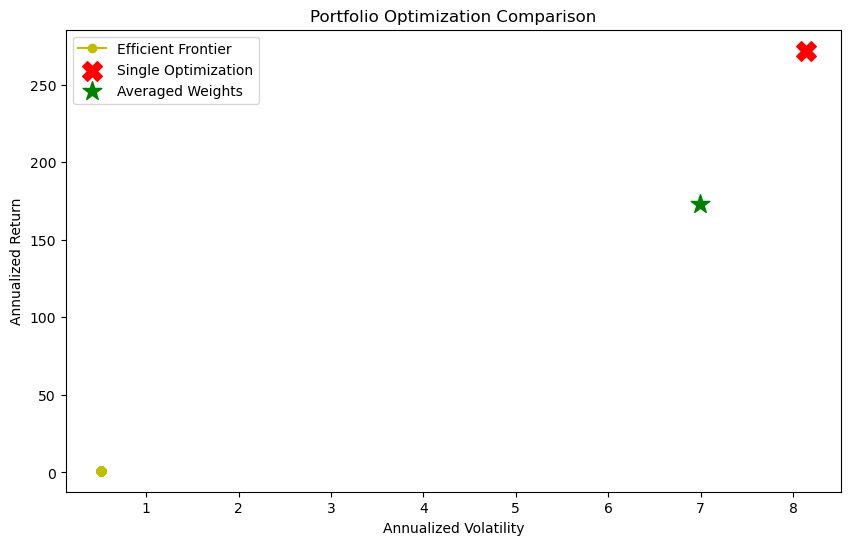

Averaged Weights: [8.32610221e-08 6.57099100e-08 4.57164157e-01 9.99998819e-02
 1.99999751e-01 3.19965980e-07 2.42835742e-01]
Single Optimization Weights: [4.24405356e-08 3.22190253e-08 9.99999007e-01 5.80224658e-08
 9.32400583e-08 1.49204575e-07 6.17793381e-07]


In [16]:
tickers = ['SPY','QQQ','UVIX']
optimizer = PortfolioOptimizer(tickers, '2023-01-01', '2025-02-19')
optimizer.run()